# ECON 5140 Final Project

## Weather, Road Context, and Accident Severity in Texas

### Research Question

How are weather conditions, visibility, lighting, and road context related to accident severity in Texas after controlling for observed crash characteristics?

### Overview

This project studies the relationship between environmental conditions, road setting, and accident severity using Texas crash data from the U.S. Accidents dataset. Because weather and lighting conditions are not randomly assigned, the estimates are interpreted as conditional associations rather than causal effects.

### Empirical Approach

The analysis uses several complementary models:

- OLS regression as a benchmark using the 1–4 severity scale
- Ordered logit as the main specification for ordinal severity outcomes
- Binary logit for the probability of high-severity crashes
- Marginal effects for probability interpretation
- Robustness checks using alternative specifications

### Main Variables

**Outcomes**

- Severity  
- HighSeverity = 1 if Severity is 3 or 4  
- Severe4 = 1 if Severity is 4  

**Key Explanatory Variables**

- Rain  
- Visibility(mi)  
- Wind_Speed(mph)  
- Temperature(F)  
- Night  
- Weekend  
- RushHour  
- Junction  
- Traffic_Signal  
- Crossing  

**Controls**

- County fixed effects  
- Month fixed effects

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
import warnings

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10

sns.set_palette("deep")

## 1. Data Preparation

The dataset is prepared by selecting Texas observations, drawing a random working sample, and constructing variables used in the empirical analysis.

In [12]:
df = pd.read_csv("tx_master_dataset.csv")
print("Original Texas sample:", df.shape)
df.head()

Original Texas sample: (572795, 23)


,Severity,Start_Time,County,City,Visibility(mi),Precipitation(in),Temperature(F),Wind_Speed(mph),Weather_Condition,Sunrise_Sunset,...,Stop,Railway,Roundabout,Hour,Month,Weekend,RushHour,Night,HighSeverity,Rain
0,2,2016-11-30 16:03:54,Travis,Austin,10.0,0.0,66.0,5.8,Clear,Day,...,False,False,False,16,11,0,1,0,0,0
1,2,2016-11-30 16:32:18,Travis,Austin,10.0,0.0,62.1,4.6,Clear,Day,...,False,False,False,16,11,0,1,0,0,0
2,2,2016-11-30 16:31:45,Travis,Austin,10.0,0.0,62.1,4.6,Clear,Day,...,False,False,False,16,11,0,1,0,0,0
3,2,2016-11-30 16:10:04,Dallas,Dallas,10.0,0.0,60.1,5.8,Clear,Day,...,False,False,False,16,11,0,1,0,0,0
4,3,2016-11-30 16:05:32,Dallas,Dallas,10.0,0.0,61.0,4.6,Clear,Day,...,False,False,False,16,11,0,1,0,1,0


In [14]:
df = df.sample(n=20000, random_state=42).copy()
print("Working sample:", df.shape)

Working sample: (20000, 23)


In [16]:
top_counties = df["County"].value_counts().head(15).index

df["County_Grouped"] = df["County"].where(
    df["County"].isin(top_counties),
    "Other"
)

In [18]:
df["HighSeverity"] = (df["Severity"] >= 3).astype(int)
df["Severe4"] = (df["Severity"] == 4).astype(int)

In [20]:
df["vis_bin"] = pd.cut(
    df["Visibility(mi)"],
    bins=[0, 1, 3, 5, 10, 100],
    labels=["0-1", "1-3", "3-5", "5-10", "10+"]
)

In [22]:
print(df[[
    "Severity",
    "HighSeverity",
    "Severe4",
    "Rain",
    "Night",
    "Weekend",
    "RushHour",
    "County_Grouped"
]].head())

        Severity  HighSeverity  Severe4  Rain  Night  Weekend  RushHour  \
108504         3             1        0     0      0        0         1   
405298         2             0        0     0      1        1         0   
10799          2             0        0     0      1        0         1   
313008         2             0        0     0      0        0         1   
406556         2             0        0     0      0        0         0   

       County_Grouped  
108504          Bexar  
405298         Travis  
10799          Harris  
313008          Bexar  
406556         Dallas  


The final working sample contains 20,000 observations. Binary severity outcomes and grouped county controls are constructed for modeling, and visibility is converted into categories for nonlinear descriptive analysis.

## 2. Descriptive Statistics

This section summarizes the main outcome variables, weather measures, and road context indicators used in the analysis.

In [27]:
summary_vars = [
    "Severity",
    "HighSeverity",
    "Severe4",
    "Visibility(mi)",
    "Precipitation(in)",
    "Temperature(F)",
    "Wind_Speed(mph)",
    "Rain",
    "Night",
    "Weekend",
    "RushHour",
    "Junction",
    "Traffic_Signal",
    "Crossing"
]

desc_table = df[summary_vars].describe().T[["mean", "std", "min", "max"]]
desc_table = desc_table.round(3)
desc_table

,mean,std,min,max
Severity,2.227,0.461,1.0,4.00
HighSeverity,0.222,0.415,0.0,1.00
Severe4,0.012,0.108,0.0,1.00
Visibility(mi),9.240,2.151,0.0,25.00
Precipitation(in),0.005,0.045,0.0,1.41
Temperature(F),70.110,16.359,1.0,109.00
Wind_Speed(mph),8.585,4.854,0.0,41.00
Rain,0.051,0.219,0.0,1.00
Night,0.280,0.449,0.0,1.00
Weekend,0.131,0.337,0.0,1.00


In [29]:
desc_table.style.format("{:.3f}").background_gradient(cmap="Blues")

,mean,std,min,max
Severity,2.227,0.461,1.000,4.000
HighSeverity,0.222,0.415,0.000,1.000
Severe4,0.012,0.108,0.000,1.000
Visibility(mi),9.240,2.151,0.000,25.000
Precipitation(in),0.005,0.045,0.000,1.410
Temperature(F),70.110,16.359,1.000,109.000
Wind_Speed(mph),8.585,4.854,0.000,41.000
Rain,0.051,0.219,0.000,1.000
Night,0.280,0.449,0.000,1.000
Weekend,0.131,0.337,0.000,1.000


The average severity in the sample is slightly above 2.2, about 22 percent of crashes are high severity, and only a small share are severity 4 crashes.

## 3. Correlation Heatmap

The heatmap below provides a descriptive view of how severity is related to weather, visibility, and road context before moving to regression analysis.

In [34]:
heat_vars = [
    "Severity",
    "HighSeverity",
    "Rain",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Night",
    "Weekend",
    "Junction",
    "Traffic_Signal",
    "Crossing"
]

corr = df[heat_vars].corr()

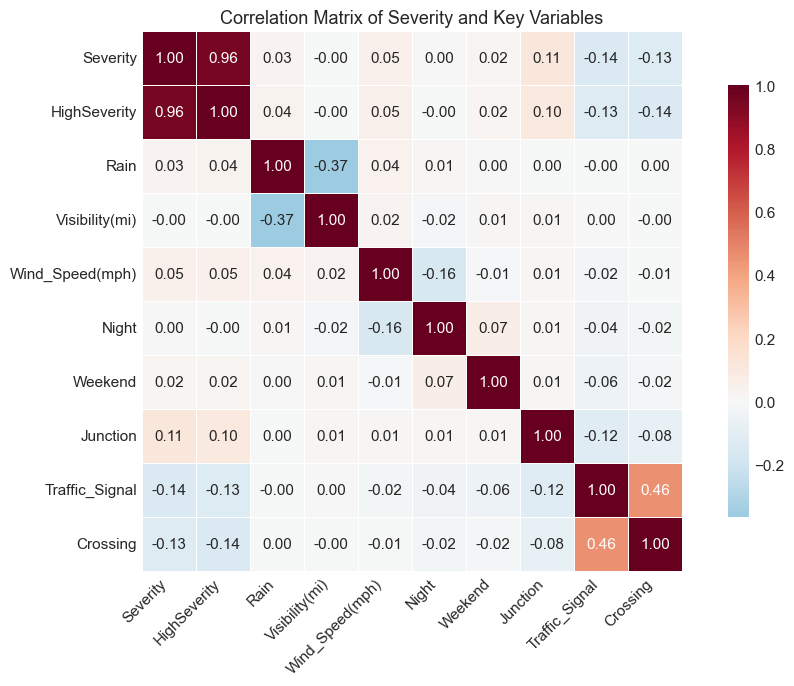

In [36]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Severity and Key Variables")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Severity is positively correlated with rain, wind speed, and junction locations, while traffic signals and crossings show negative correlations with severity outcomes.

## 4. Descriptive Patterns

The figures below show how severity patterns vary across weather conditions, time of day, visibility, and road environment.

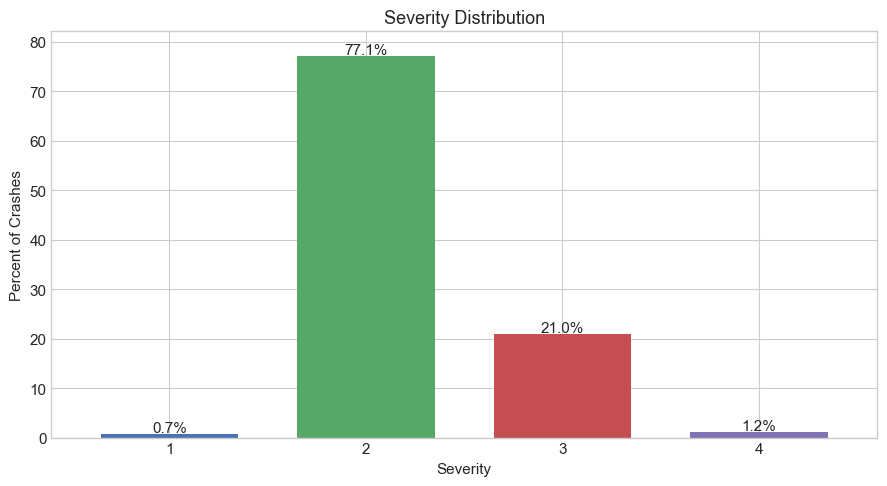

In [43]:
sev = df["Severity"].value_counts(normalize=True).sort_index() * 100

ax = sev.plot(kind="bar", color=["#4C72B0", "#55A868", "#C44E52", "#8172B3"], width=0.7)
plt.title("Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Percent of Crashes")
plt.xticks(rotation=0)

for i, v in enumerate(sev):
    ax.text(i, v + 0.4, f"{v:.1f}%", ha="center")

plt.ylim(0, sev.max() + 5)
plt.tight_layout()
plt.show()

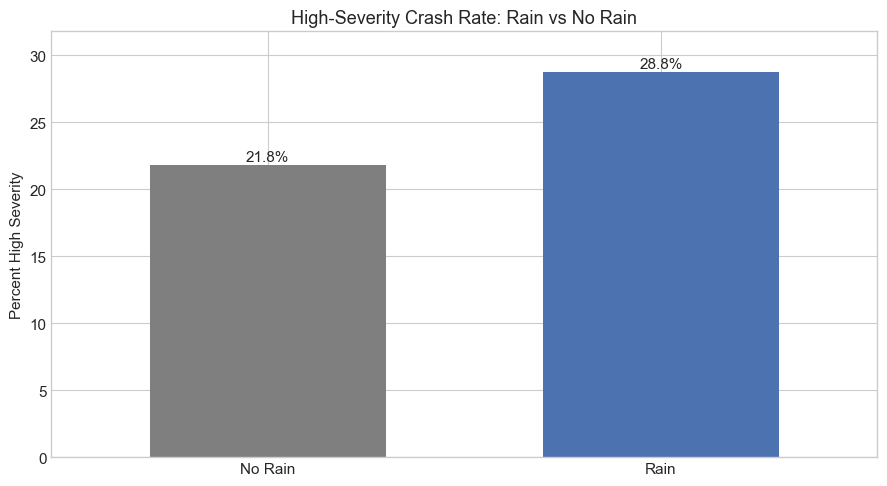

In [45]:
rain = df.groupby("Rain")["HighSeverity"].mean() * 100
rain.index = ["No Rain", "Rain"]

ax = rain.plot(kind="bar", color=["#7F7F7F", "#4C72B0"], width=0.6)
plt.title("High-Severity Crash Rate: Rain vs No Rain")
plt.xlabel("")
plt.ylabel("Percent High Severity")
plt.xticks(rotation=0)

for i, v in enumerate(rain):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center")

plt.ylim(0, rain.max() + 3)
plt.tight_layout()
plt.show()

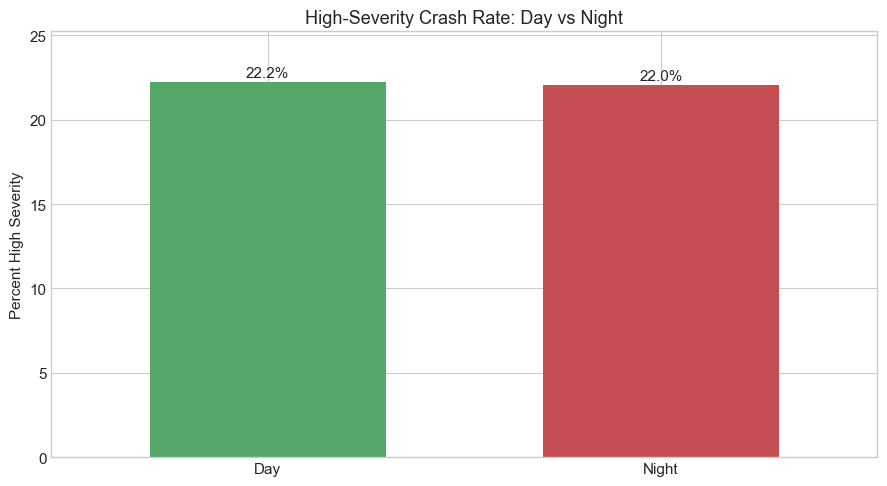

In [47]:
night = df.groupby("Night")["HighSeverity"].mean() * 100
night.index = ["Day", "Night"]

ax = night.plot(kind="bar", color=["#55A868", "#C44E52"], width=0.6)
plt.title("High-Severity Crash Rate: Day vs Night")
plt.xlabel("")
plt.ylabel("Percent High Severity")
plt.xticks(rotation=0)

for i, v in enumerate(night):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center")

plt.ylim(0, night.max() + 3)
plt.tight_layout()
plt.show()

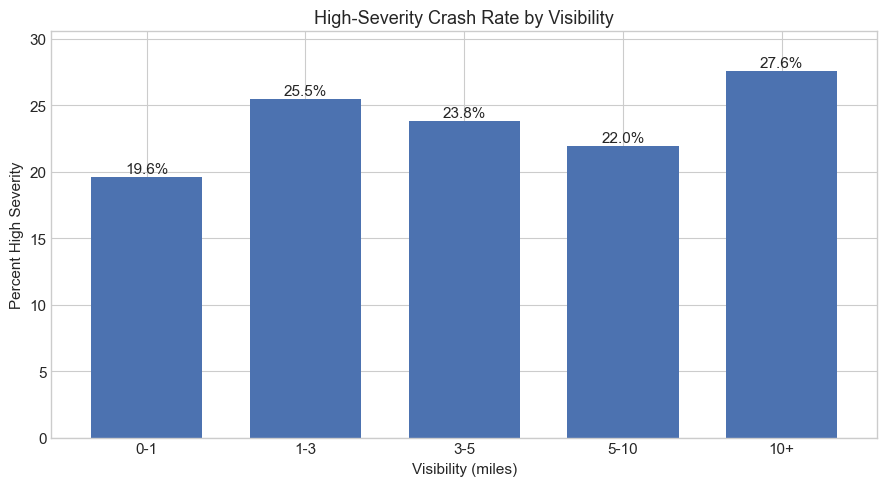

In [49]:
vis = df.groupby("vis_bin", observed=True)["HighSeverity"].mean() * 100

ax = vis.plot(kind="bar", color="#4C72B0", width=0.7)
plt.title("High-Severity Crash Rate by Visibility")
plt.xlabel("Visibility (miles)")
plt.ylabel("Percent High Severity")
plt.xticks(rotation=0)

for i, v in enumerate(vis):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center")

plt.ylim(0, vis.max() + 3)
plt.tight_layout()
plt.show()

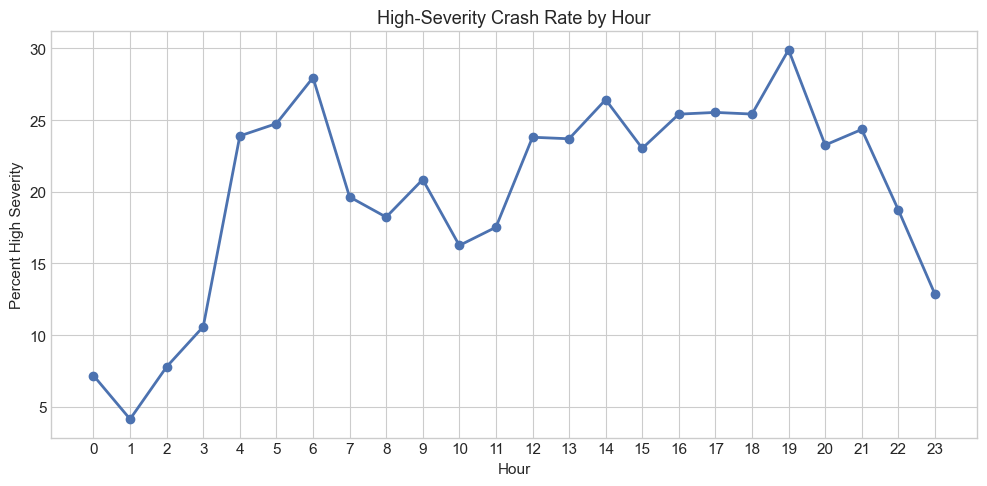

In [51]:
hour = df.groupby("Hour")["HighSeverity"].mean() * 100

plt.figure(figsize=(10, 5))
plt.plot(hour.index, hour.values, marker="o", linewidth=2, color="#4C72B0")
plt.title("High-Severity Crash Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Percent High Severity")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

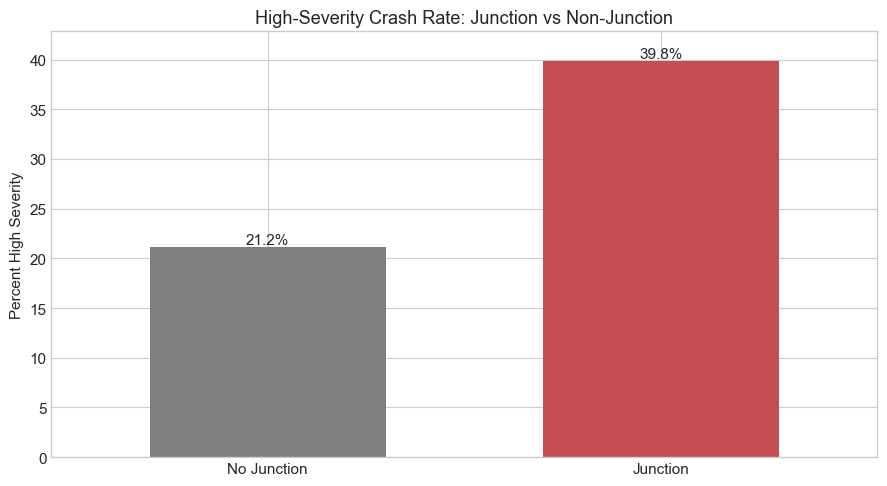

In [53]:
jun = df.groupby("Junction")["HighSeverity"].mean() * 100
jun.index = ["No Junction", "Junction"]

ax = jun.plot(kind="bar", color=["#7F7F7F", "#C44E52"], width=0.6)
plt.title("High-Severity Crash Rate: Junction vs Non-Junction")
plt.xlabel("")
plt.ylabel("Percent High Severity")
plt.xticks(rotation=0)

for i, v in enumerate(jun):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center")

plt.ylim(0, jun.max() + 3)
plt.tight_layout()
plt.show()

The descriptive evidence suggests that high-severity crashes are more common in rain and at junctions. Severity also varies over the day, while the visibility pattern appears weaker and less monotonic.

## 5. OLS Benchmark Model

The first model estimates accident severity on the 1–4 scale using OLS as a benchmark specification with county and month fixed effects.

In [66]:
ols = smf.ols("""
Severity ~
Q("Visibility(mi)") +
Rain +
Q("Temperature(F)") +
Q("Wind_Speed(mph)") +
Night +
RushHour +
Weekend +
Junction +
Traffic_Signal +
Crossing +
C(County_Grouped) +
C(Month)
""", data=df).fit(cov_type="HC1")

In [68]:
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:               Severity   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     89.17
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:50:53   Log-Likelihood:                -11984.
No. Observations:               20000   AIC:                         2.404e+04
Df Residuals:                   19963   BIC:                         2.434e+04
Df Model:                          36                                         
Covariance Type:                  HC1                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

In [70]:
key_ols = pd.Series({
    "Rain": ols.params["Rain"],
    "Visibility": ols.params['Q("Visibility(mi)")'],
    "Wind Speed": ols.params['Q("Wind_Speed(mph)")'],
    "Night": ols.params["Night"],
    "Weekend": ols.params["Weekend"],
    "Junction": ols.params["Junction[T.True]"],
    "Traffic Signal": ols.params["Traffic_Signal[T.True]"],
    "Crossing": ols.params["Crossing[T.True]"]
}).sort_values()

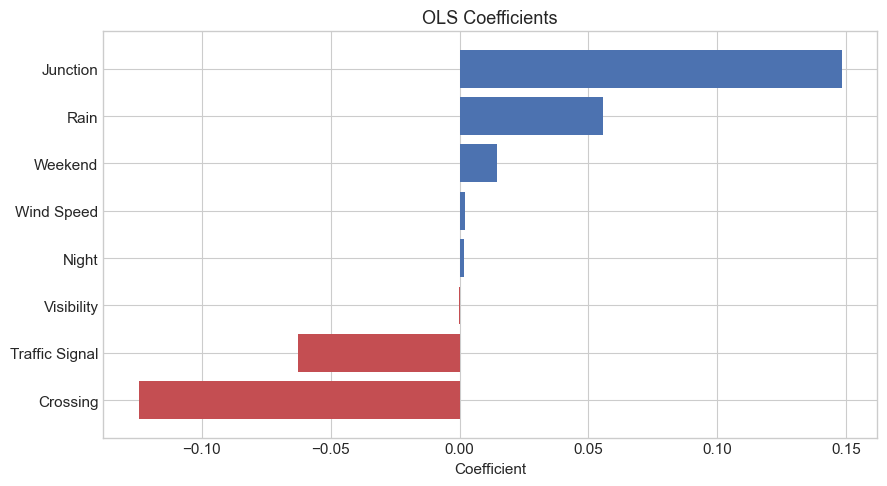

In [72]:
colors = ["#C44E52" if x < 0 else "#4C72B0" for x in key_ols.values]

plt.figure(figsize=(9,5))
plt.barh(key_ols.index, key_ols.values, color=colors)
plt.title("OLS Coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

Rain, wind speed, and junction locations are positively associated with severity, while traffic signals and crossings are associated with lower severity outcomes. OLS is used as a benchmark and does not impose the ordinal structure of the dependent variable.

## 6. Ordered Logit Model

Severity is an ordered outcome from 1 to 4, so ordered logit is the main specification.

In [77]:
X = df[[
    "Visibility(mi)",
    "Rain",
    "Temperature(F)",
    "Wind_Speed(mph)",
    "Night",
    "RushHour",
    "Weekend"
]]

y = df["Severity"]

In [79]:
ordered = OrderedModel(
    y,
    X,
    distr="logit"
)

ordered_result = ordered.fit(method="bfgs", disp=False)

In [81]:
print(ordered_result.summary())

                             OrderedModel Results                             
Dep. Variable:               Severity   Log-Likelihood:                -12253.
Model:                   OrderedModel   AIC:                         2.453e+04
Method:            Maximum Likelihood   BIC:                         2.461e+04
Date:                Fri, 17 Apr 2026                                         
Time:                        19:52:30                                         
No. Observations:               20000                                         
Df Residuals:                   19990                                         
Df Model:                           7                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Visibility(mi)      0.0080      0.009      0.925      0.355      -0.009       0.025
Rain                0.3697      0.078

In [83]:
key_ord = pd.Series({
    "Rain": ordered_result.params["Rain"],
    "Visibility": ordered_result.params["Visibility(mi)"],
    "Wind Speed": ordered_result.params["Wind_Speed(mph)"],
    "Night": ordered_result.params["Night"],
    "Weekend": ordered_result.params["Weekend"],
    "Rush Hour": ordered_result.params["RushHour"]
}).sort_values()

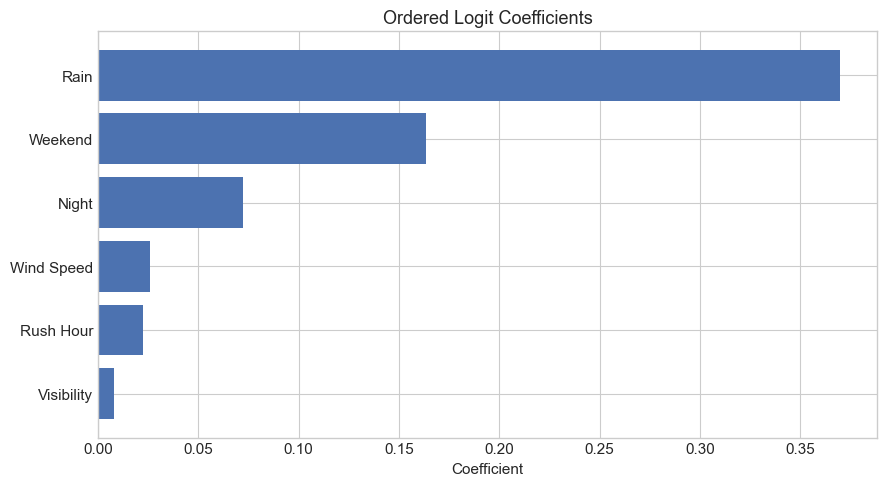

In [85]:
colors = ["#C44E52" if x < 0 else "#4C72B0" for x in key_ord.values]

plt.figure(figsize=(9,5))
plt.barh(key_ord.index, key_ord.values, color=colors)
plt.title("Ordered Logit Coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

The ordered logit results indicate that rain, wind speed, and weekend conditions are associated with movement toward higher severity categories. This specification is preferred because it respects the ranking of severity levels.

## 7. Binary Logit Model

This model estimates the probability that a crash is high severity, where HighSeverity = 1 if Severity is 3 or 4.

In [90]:
logit = smf.logit("""
HighSeverity ~
Q("Visibility(mi)") +
Rain +
Q("Temperature(F)") +
Q("Wind_Speed(mph)") +
Night +
RushHour +
Weekend +
Junction +
Traffic_Signal +
Crossing +
C(Month)
""", data=df).fit(disp=False)

In [92]:
print(logit.summary())

                           Logit Regression Results                           
Dep. Variable:           HighSeverity   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19978
Method:                           MLE   Df Model:                           21
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                 0.04213
Time:                        19:53:54   Log-Likelihood:                -10138.
converged:                       True   LL-Null:                       -10584.
Covariance Type:            nonrobust   LLR p-value:                3.029e-175
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -1.4361      0.140    -10.270      0.000      -1.710      -1.162
Junction[T.True]           0.7113      0.065     10.862      0.000       0.583       0.840
Traf

In [94]:
key_logit = pd.Series({
    "Rain": logit.params["Rain"],
    "Visibility": logit.params['Q("Visibility(mi)")'],
    "Wind Speed": logit.params['Q("Wind_Speed(mph)")'],
    "Night": logit.params["Night"],
    "Weekend": logit.params["Weekend"],
    "Junction": logit.params["Junction[T.True]"],
    "Traffic Signal": logit.params["Traffic_Signal[T.True]"],
    "Crossing": logit.params["Crossing[T.True]"]
}).sort_values()

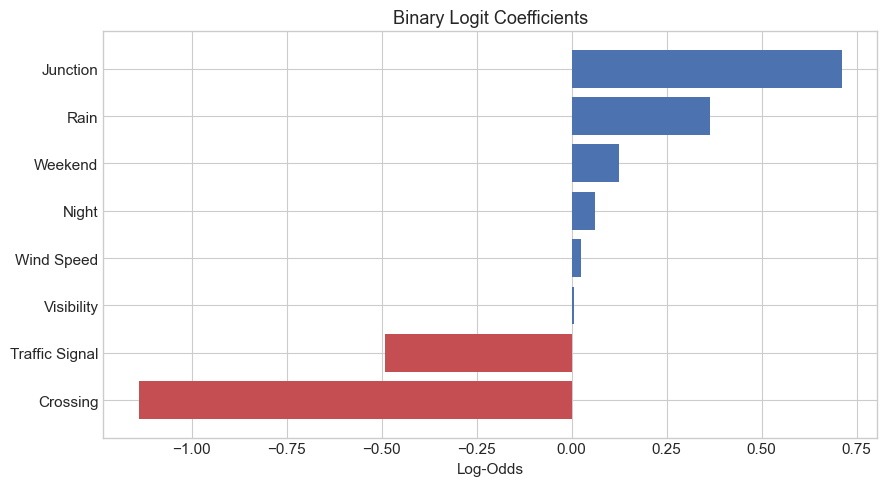

In [96]:
colors = ["#C44E52" if x < 0 else "#4C72B0" for x in key_logit.values]

plt.figure(figsize=(9,5))
plt.barh(key_logit.index, key_logit.values, color=colors)
plt.title("Binary Logit Coefficients")
plt.xlabel("Log-Odds")
plt.tight_layout()
plt.show()

Rain, wind speed, weekend timing, and junction locations are associated with a higher probability of severe crashes, while traffic signals and crossings are associated with lower probability outcomes.

## 8. Marginal Effects

Marginal effects translate the logit coefficients into changes in the probability of a high-severity crash.

In [101]:
mfx = logit.get_margeff()
print(mfx.summary())

        Logit Marginal Effects       
Dep. Variable:           HighSeverity
Method:                          dydx
At:                           overall
                            dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Junction[T.True]           0.1177      0.011     10.976      0.000       0.097       0.139
Traffic_Signal[T.True]    -0.0814      0.008    -10.014      0.000      -0.097      -0.065
Crossing[T.True]          -0.1887      0.014    -13.132      0.000      -0.217      -0.161
C(Month)[T.2]              0.0116      0.014      0.820      0.412      -0.016       0.039
C(Month)[T.3]              0.0450      0.015      3.083      0.002       0.016       0.074
C(Month)[T.4]              0.0463      0.015      3.141      0.002       0.017       0.075
C(Month)[T.5]              0.0708      0.016      4.532      0.000       0.040       0.101
C(Month)[T.6]              0.

In [103]:
mfx_df = mfx.summary_frame().reset_index()
mfx_df.columns = ["Variable", "Effect", "StdErr", "z", "PValue", "CI_Low", "CI_High"]

In [105]:
keep = [
    "Rain",
    'Q("Visibility(mi)")',
    'Q("Wind_Speed(mph)")',
    "Night",
    "Weekend",
    "Junction[T.True]",
    "Traffic_Signal[T.True]",
    "Crossing[T.True]"
]

mfx_df = mfx_df[mfx_df["Variable"].isin(keep)].copy()

In [107]:
rename_map = {
    "Rain": "Rain",
    'Q("Visibility(mi)")': "Visibility",
    'Q("Wind_Speed(mph)")': "Wind Speed",
    "Night": "Night",
    "Weekend": "Weekend",
    "Junction[T.True]": "Junction",
    "Traffic_Signal[T.True]": "Traffic Signal",
    "Crossing[T.True]": "Crossing"
}

mfx_df["Variable"] = mfx_df["Variable"].map(rename_map)
mfx_df = mfx_df.sort_values("Effect")

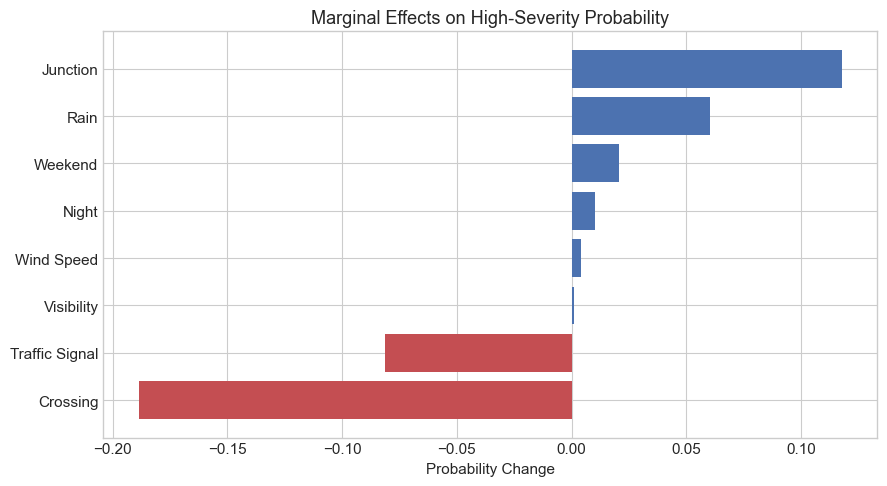

In [109]:
colors = ["#C44E52" if x < 0 else "#4C72B0" for x in mfx_df["Effect"]]

plt.figure(figsize=(9,5))
plt.barh(mfx_df["Variable"], mfx_df["Effect"], color=colors)
plt.title("Marginal Effects on High-Severity Probability")
plt.xlabel("Probability Change")
plt.tight_layout()
plt.show()

## 9. Robustness Checks

Additional specifications test whether the main findings remain stable under alternative definitions and interaction terms.

### 9.1 Rain and Night Interaction

In [114]:
df["RainNight"] = df["Rain"] * df["Night"]

In [116]:
logit_inter = smf.logit("""
HighSeverity ~
Rain +
Night +
RainNight +
Q("Visibility(mi)") +
Q("Wind_Speed(mph)") +
Weekend +
Junction +
Traffic_Signal +
Crossing +
C(Month)
""", data=df).fit(disp=False)

In [118]:
print(logit_inter.summary())

                           Logit Regression Results                           
Dep. Variable:           HighSeverity   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19979
Method:                           MLE   Df Model:                           20
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                 0.04200
Time:                        19:57:07   Log-Likelihood:                -10139.
converged:                       True   LL-Null:                       -10584.
Covariance Type:            nonrobust   LLR p-value:                1.692e-175
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -1.5525      0.107    -14.560      0.000      -1.762      -1.344
Junction[T.True]           0.7142      0.065     10.910      0.000       0.586       0.843
Traf

In [120]:
interaction_df = pd.DataFrame({
    "Rain": [0, 0, 1, 1],
    "Night": [0, 1, 0, 1],
    "RainNight": [0, 0, 0, 1],
    "Visibility(mi)": df["Visibility(mi)"].mean(),
    "Wind_Speed(mph)": df["Wind_Speed(mph)"].mean(),
    "Weekend": 0,
    "Junction": False,
    "Traffic_Signal": False,
    "Crossing": False,
    "Month": 1
})

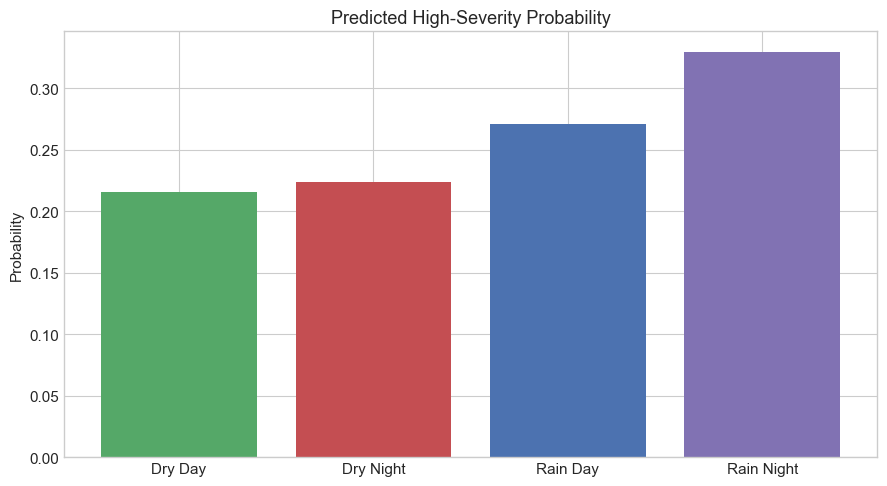

In [122]:
interaction_df["PredictedProb"] = logit_inter.predict(interaction_df)

labels = ["Dry Day", "Dry Night", "Rain Day", "Rain Night"]

plt.figure(figsize=(9,5))
plt.bar(
    labels,
    interaction_df["PredictedProb"],
    color=["#55A868", "#C44E52", "#4C72B0", "#8172B3"]
)
plt.title("Predicted High-Severity Probability")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

The interaction model tests whether rain conditions are associated with different severity patterns during nighttime crashes.

### 9.2 Extreme Severity Outcome

In [126]:
logit4 = smf.logit("""
Severe4 ~
Rain +
Night +
Q("Visibility(mi)") +
Q("Wind_Speed(mph)") +
Weekend +
Junction +
Traffic_Signal +
Crossing +
C(Month)
""", data=df).fit(disp=False)

In [128]:
print(logit4.summary())

                           Logit Regression Results                           
Dep. Variable:                Severe4   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19980
Method:                           MLE   Df Model:                           19
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                 0.05451
Time:                        19:58:14   Log-Likelihood:                -1208.3
converged:                       True   LL-Null:                       -1277.9
Covariance Type:            nonrobust   LLR p-value:                 2.467e-20
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -4.5761      0.419    -10.909      0.000      -5.398      -3.754
Junction[T.True]           1.1496      0.174      6.624      0.000       0.809       1.490
Traf

In [130]:
key_logit4 = pd.Series({
    "Rain": logit4.params["Rain"],
    "Visibility": logit4.params['Q("Visibility(mi)")'],
    "Wind Speed": logit4.params['Q("Wind_Speed(mph)")'],
    "Night": logit4.params["Night"],
    "Weekend": logit4.params["Weekend"],
    "Junction": logit4.params["Junction[T.True]"],
    "Traffic Signal": logit4.params["Traffic_Signal[T.True]"],
    "Crossing": logit4.params["Crossing[T.True]"]
}).sort_values()

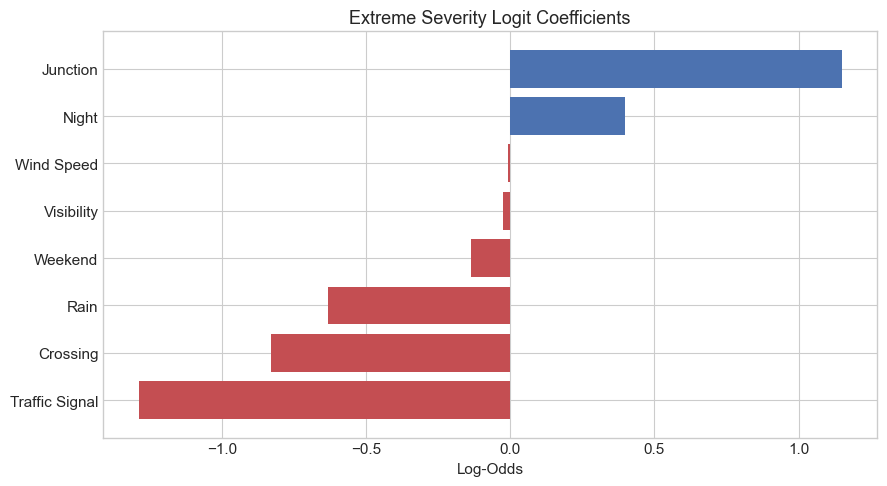

In [132]:
colors = ["#C44E52" if x < 0 else "#4C72B0" for x in key_logit4.values]

plt.figure(figsize=(9,5))
plt.barh(key_logit4.index, key_logit4.values, color=colors)
plt.title("Extreme Severity Logit Coefficients")
plt.xlabel("Log-Odds")
plt.tight_layout()
plt.show()

The results remain broadly consistent when allowing interaction effects and when focusing only on the most severe crashes.

## 10. County-Clustered Standard Errors

Crashes within the same county may share common road conditions, reporting environments, and traffic patterns. To account for within-county correlation, the main binary logit model is re-estimated with county-clustered standard errors.

In [137]:
logit_cluster = smf.logit("""
HighSeverity ~
Q("Visibility(mi)") +
Rain +
Q("Temperature(F)") +
Q("Wind_Speed(mph)") +
Night +
RushHour +
Weekend +
Junction +
Traffic_Signal +
Crossing +
C(Month)
""", data=df).fit(
    disp=False,
    cov_type="cluster",
    cov_kwds={"groups": df["County_Grouped"]}
)

In [139]:
print(logit_cluster.summary())

                           Logit Regression Results                           
Dep. Variable:           HighSeverity   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19978
Method:                           MLE   Df Model:                           21
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                 0.04213
Time:                        19:59:39   Log-Likelihood:                -10138.
converged:                       True   LL-Null:                       -10584.
Covariance Type:              cluster   LLR p-value:                3.029e-175
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -1.4361      0.355     -4.046      0.000      -2.132      -0.740
Junction[T.True]           0.7113      0.249      2.860      0.004       0.224       1.199
Traf

In [141]:
cluster_compare = pd.DataFrame({
    "Coefficient": [
        logit.params["Rain"],
        logit.params['Q("Wind_Speed(mph)")'],
        logit.params["Junction[T.True]"],
        logit.params["Traffic_Signal[T.True]"],
        logit.params["Crossing[T.True]"]
    ],
    "SE Robust": [
        logit.bse["Rain"],
        logit.bse['Q("Wind_Speed(mph)")'],
        logit.bse["Junction[T.True]"],
        logit.bse["Traffic_Signal[T.True]"],
        logit.bse["Crossing[T.True]"]
    ],
    "SE Clustered": [
        logit_cluster.bse["Rain"],
        logit_cluster.bse['Q("Wind_Speed(mph)")'],
        logit_cluster.bse["Junction[T.True]"],
        logit_cluster.bse["Traffic_Signal[T.True]"],
        logit_cluster.bse["Crossing[T.True]"]
    ]
}, index=[
    "Rain",
    "Wind Speed",
    "Junction",
    "Traffic Signal",
    "Crossing"
]).round(4)

cluster_compare

,Coefficient,SE Robust,SE Clustered
Rain,0.3633,0.0806,0.1554
Wind Speed,0.0253,0.0037,0.0099
Junction,0.7113,0.0655,0.2487
Traffic Signal,-0.4921,0.0494,0.0541
Crossing,-1.1403,0.0872,0.2243


In [143]:
cluster_compare.style.background_gradient(cmap="Blues")

,Coefficient,SE Robust,SE Clustered
Rain,0.363300,0.080600,0.155400
Wind Speed,0.025300,0.003700,0.009900
Junction,0.711300,0.065500,0.248700
Traffic Signal,-0.492100,0.049400,0.054100
Crossing,-1.140300,0.087200,0.224300


The main relationships remain stable after clustering standard errors at the county level, suggesting that the findings are not driven by understated statistical uncertainty.

## 11. Model Evaluation

The binary logit model is evaluated using out-of-sample predictive performance on a holdout sample.

In [148]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [150]:
model_df = df[[
    "HighSeverity",
    "Visibility(mi)",
    "Rain",
    "Temperature(F)",
    "Wind_Speed(mph)",
    "Night",
    "RushHour",
    "Weekend",
    "Junction",
    "Traffic_Signal",
    "Crossing",
    "Month"
]].dropna().copy()

In [152]:
train_df, test_df = train_test_split(
    model_df,
    test_size=0.30,
    random_state=42
)

In [154]:
logit_eval = smf.logit("""
HighSeverity ~
Q("Visibility(mi)") +
Rain +
Q("Temperature(F)") +
Q("Wind_Speed(mph)") +
Night +
RushHour +
Weekend +
Junction +
Traffic_Signal +
Crossing +
C(Month)
""", data=train_df).fit(disp=False)

In [156]:
pred_prob = logit_eval.predict(test_df)
pred_class = (pred_prob >= 0.5).astype(int)

In [158]:
acc = accuracy_score(test_df["HighSeverity"], pred_class)
auc = roc_auc_score(test_df["HighSeverity"], pred_prob)
cm = confusion_matrix(test_df["HighSeverity"], pred_class)

print("Accuracy:", round(acc, 3))
print("AUC:", round(auc, 3))
print()
print(classification_report(test_df["HighSeverity"], pred_class))

Accuracy: 0.767
AUC: 0.633

              precision    recall  f1-score   support

           0       0.77      1.00      0.87      4606
           1       0.38      0.00      0.01      1394

    accuracy                           0.77      6000
   macro avg       0.57      0.50      0.44      6000
weighted avg       0.68      0.77      0.67      6000



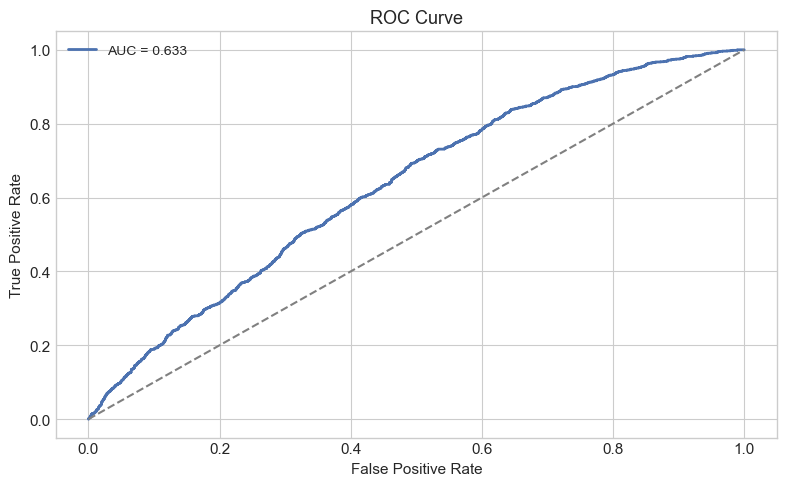

In [160]:
fpr, tpr, _ = roc_curve(test_df["HighSeverity"], pred_prob)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}", color="#4C72B0")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

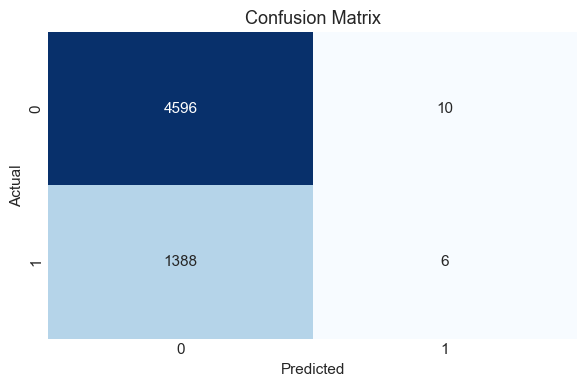

In [162]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

The model shows moderate predictive power. The AUC provides a more informative measure than raw accuracy because severe crashes are less common than non-severe crashes in the sample.

## 12. Summary Results Comparison

The table below compares key estimates across the main model specifications.

In [169]:
summary_table = pd.DataFrame(index=[
    "Rain",
    "Visibility",
    "Wind Speed",
    "Night",
    "Weekend",
    "Junction",
    "Traffic Signal",
    "Crossing"
])

In [171]:
summary_table["OLS"] = [
    ols.params["Rain"],
    ols.params['Q("Visibility(mi)")'],
    ols.params['Q("Wind_Speed(mph)")'],
    ols.params["Night"],
    ols.params["Weekend"],
    ols.params["Junction[T.True]"],
    ols.params["Traffic_Signal[T.True]"],
    ols.params["Crossing[T.True]"]
]

In [173]:
summary_table["Ordered Logit"] = [
    ordered_result.params["Rain"],
    ordered_result.params["Visibility(mi)"],
    ordered_result.params["Wind_Speed(mph)"],
    ordered_result.params["Night"],
    ordered_result.params["Weekend"],
    np.nan,
    np.nan,
    np.nan
]

In [175]:
summary_table["Binary Logit"] = [
    logit.params["Rain"],
    logit.params['Q("Visibility(mi)")'],
    logit.params['Q("Wind_Speed(mph)")'],
    logit.params["Night"],
    logit.params["Weekend"],
    logit.params["Junction[T.True]"],
    logit.params["Traffic_Signal[T.True]"],
    logit.params["Crossing[T.True]"]
]

In [177]:
summary_table["Marginal Effect"] = [
    mfx.summary_frame().loc["Rain", "dy/dx"],
    mfx.summary_frame().loc['Q("Visibility(mi)")', "dy/dx"],
    mfx.summary_frame().loc['Q("Wind_Speed(mph)")', "dy/dx"],
    mfx.summary_frame().loc["Night", "dy/dx"],
    mfx.summary_frame().loc["Weekend", "dy/dx"],
    mfx.summary_frame().loc["Junction[T.True]", "dy/dx"],
    mfx.summary_frame().loc["Traffic_Signal[T.True]", "dy/dx"],
    mfx.summary_frame().loc["Crossing[T.True]", "dy/dx"]
]

In [179]:
summary_table = summary_table.round(3)
summary_table

,OLS,Ordered Logit,Binary Logit,Marginal Effect
Rain,0.056,0.370,0.363,0.060
Visibility,-0.000,0.008,0.007,0.001
Wind Speed,0.002,0.026,0.025,0.004
Night,0.002,0.072,0.062,0.010
Weekend,0.014,0.164,0.124,0.021
Junction,0.148,NaN,0.711,0.118
Traffic Signal,-0.062,NaN,-0.492,-0.081
Crossing,-0.124,NaN,-1.140,-0.189


In [183]:
summary_table.style\
    .format("{:.3f}")\
    .background_gradient(cmap="RdBu_r", axis=None)

,OLS,Ordered Logit,Binary Logit,Marginal Effect
Rain,0.056,0.370,0.363,0.060
Visibility,-0.000,0.008,0.007,0.001
Wind Speed,0.002,0.026,0.025,0.004
Night,0.002,0.072,0.062,0.010
Weekend,0.014,0.164,0.124,0.021
Junction,0.148,nan,0.711,0.118
Traffic Signal,-0.062,nan,-0.492,-0.081
Crossing,-0.124,nan,-1.140,-0.189


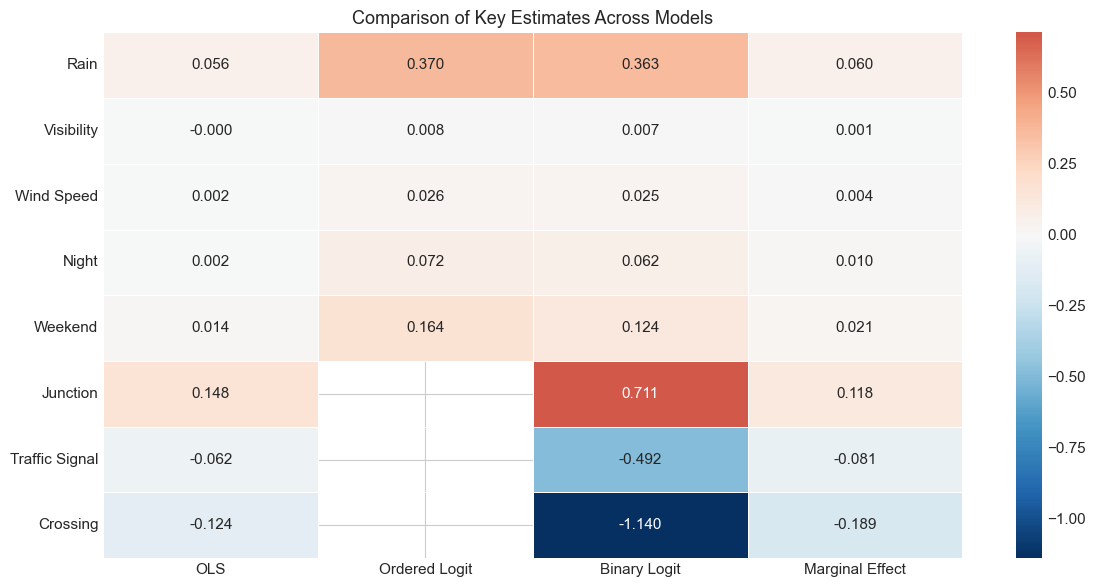

In [185]:
plt.figure(figsize=(12,6))
sns.heatmap(
    summary_table,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)
plt.title("Comparison of Key Estimates Across Models")
plt.tight_layout()
plt.show()

Rain, wind speed, and junction locations are positively associated with severity across multiple specifications, while traffic signals and crossings are consistently associated with lower severity outcomes.

## 13. National Comparison

This section places the Texas findings in a broader national context using a random sample of 200,000 U.S. accident records.

In [190]:
us = pd.read_csv(
    "US_Accidents_March23.csv",
    usecols=[
        "Severity",
        "State",
        "City",
        "Start_Time",
        "Weather_Condition",
        "Sunrise_Sunset"
    ]
)

In [191]:
us = us.sample(200000, random_state=42).copy()
print(us.shape)

(200000, 6)


In [194]:
us["HighSeverity"] = (us["Severity"] >= 3).astype(int)

us["Rain"] = us["Weather_Condition"].fillna("").str.contains(
    "Rain",
    case=False
).astype(int)

us["Night"] = (us["Sunrise_Sunset"] == "Night").astype(int)

us["Start_Time"] = pd.to_datetime(
    us["Start_Time"],
    errors="coerce",
    format="mixed"
)

us["Month"] = us["Start_Time"].dt.month

### 13.1 Top States by Crash Count

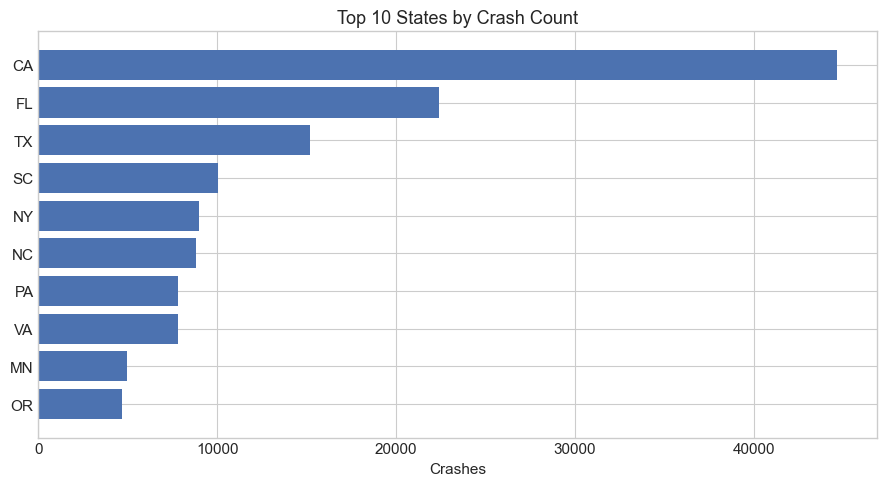

In [197]:
top_states = us["State"].value_counts().head(10).sort_values()

plt.figure(figsize=(9,5))
plt.barh(top_states.index, top_states.values, color="#4C72B0")
plt.title("Top 10 States by Crash Count")
plt.xlabel("Crashes")
plt.tight_layout()
plt.show()

### 13.2 Top Cities by Crash Count

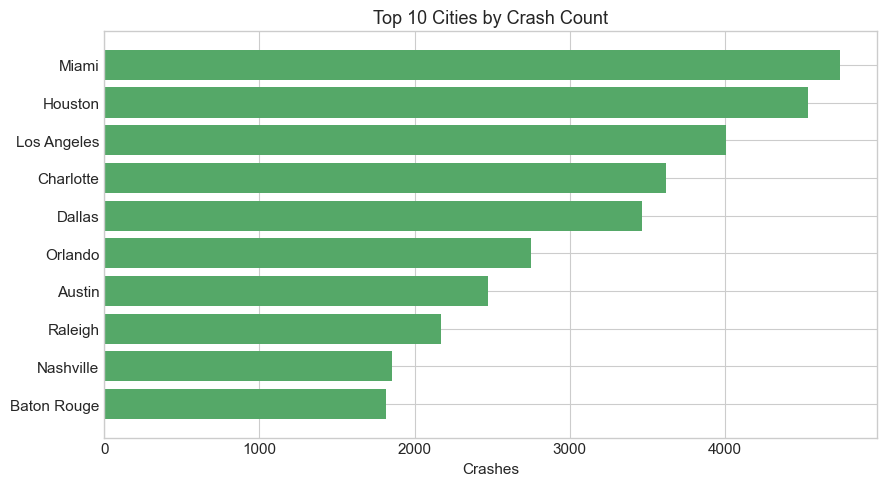

In [200]:
top_cities = us["City"].value_counts().head(10).sort_values()

plt.figure(figsize=(9,5))
plt.barh(top_cities.index, top_cities.values, color="#55A868")
plt.title("Top 10 Cities by Crash Count")
plt.xlabel("Crashes")
plt.tight_layout()
plt.show()

### 13.3 Texas and U.S. Comparison

In [203]:
tx = us[us["State"] == "TX"]

comparison = pd.DataFrame({
    "Texas": [
        tx["Severity"].mean(),
        tx["HighSeverity"].mean() * 100,
        tx["Rain"].mean() * 100,
        tx["Night"].mean() * 100
    ],
    "U.S. Sample": [
        us["Severity"].mean(),
        us["HighSeverity"].mean() * 100,
        us["Rain"].mean() * 100,
        us["Night"].mean() * 100
    ]
},
index=[
    "Average Severity",
    "High Severity %",
    "Rain Crashes %",
    "Night Crashes %"
]).round(2)

comparison

,Texas,U.S. Sample
Average Severity,2.23,2.21
High Severity %,22.10,19.58
Rain Crashes %,5.53,6.59
Night Crashes %,28.32,30.77


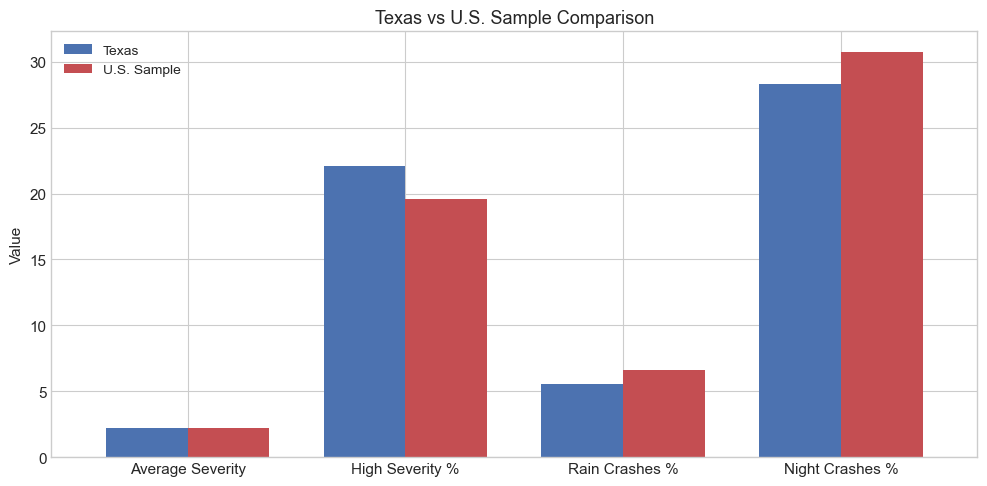

In [205]:
comparison.plot(
    kind="bar",
    figsize=(10,5),
    color=["#4C72B0", "#C44E52"],
    width=0.75
)

plt.title("Texas vs U.S. Sample Comparison")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 13.4 Average Severity by Month

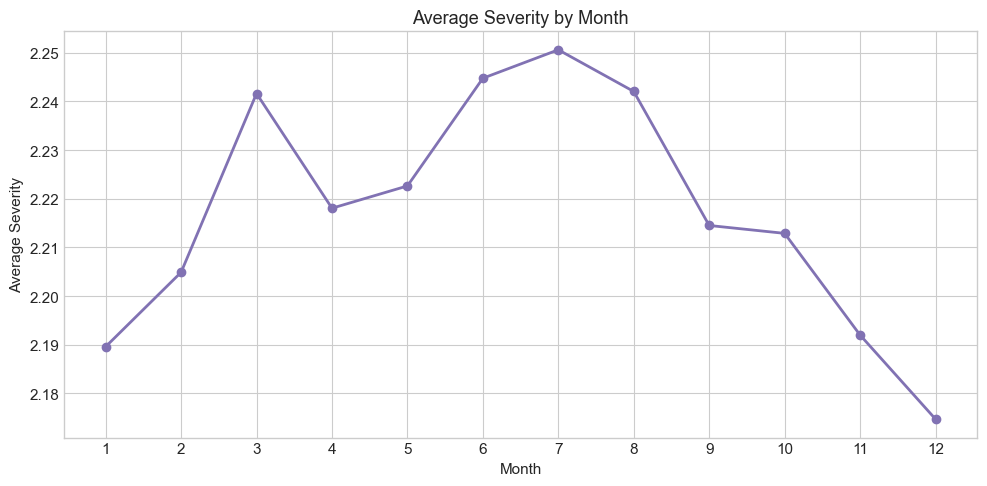

In [208]:
month_avg = us.groupby("Month")["Severity"].mean()

plt.figure(figsize=(10,5))
plt.plot(
    month_avg.index,
    month_avg.values,
    marker="o",
    linewidth=2,
    color="#8172B3"
)

plt.title("Average Severity by Month")
plt.xlabel("Month")
plt.ylabel("Average Severity")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

Texas broadly follows national patterns, while still providing a large and policy-relevant setting for the main empirical analysis.

## 14. Limitations

Several limitations should be considered when interpreting the results.

- Weather and lighting conditions are not randomly assigned.
- Driver behavior, speed choice, and traffic volume are not directly observed.
- Reported crashes may differ from unreported incidents.
- The estimates describe severity conditional on recorded crashes, not total crash risk.
- Results should be interpreted as conditional associations rather than causal effects.

## 15. Conclusion

This project examined how weather conditions and road context are related to accident severity in Texas using data from the U.S. Accidents dataset.

Across multiple specifications, rain, wind speed, and junction locations were consistently associated with greater crash severity. Traffic signals and crossings were associated with lower severity outcomes. The ordered logit model, which is appropriate for ordinal severity categories, produced results that were broadly consistent with the OLS and binary logit estimates.

Robustness checks, county-clustered standard errors, and out-of-sample model evaluation supported the stability of the main findings.

Overall, the evidence suggests that environmental conditions and road design are strongly related to crash severity and may help inform traffic safety planning, infrastructure prioritization, and risk management.